In [1]:
import utils
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path

In [2]:
# extract all the drugs from our results that correspond to the primary tumor list
df = pd.read_excel("../data/drugs_for_each_case_in_one_sheet.xlsx")
df_primary = df[df["Patient"].isin(utils.list_primary)]

In [3]:
#extract the solutions for the generic case
my_all = df[df["Patient"]=="all"]['Drug'].tolist()
res=df_primary[df_primary['Drug'].isin(my_all)]['Drug'].value_counts()

In [4]:
# see the correspondence between the generic case and the individual cases
all_cases = df_primary['Patient'].nunique()
df_filtrat = df_primary[df_primary['Drug'].isin(my_all)]
appearances = df_filtrat.groupby('Drug')['Patient'].nunique()
percent = appearances/all_cases
appearances = appearances.reindex(my_all, fill_value=0)
percent = appearances / all_cases
result = {
    "obtained in 100% cases": (percent == 1).sum(),
    "obtained in [90%,100) cases": ((percent >= 0.9) & (percent < 1)).sum(),
    "obtained in [50%, 90%) cases": ((percent >= 0.5) & (percent < 0.9)).sum(),
    "obtained in less than 50% cases": (percent < 0.5).sum()
}
print(result)

{'obtained in 100% cases': 42, 'obtained in [90%,100) cases': 33, 'obtained in [50%, 90%) cases': 48, 'obtained in less than 50% cases': 16}


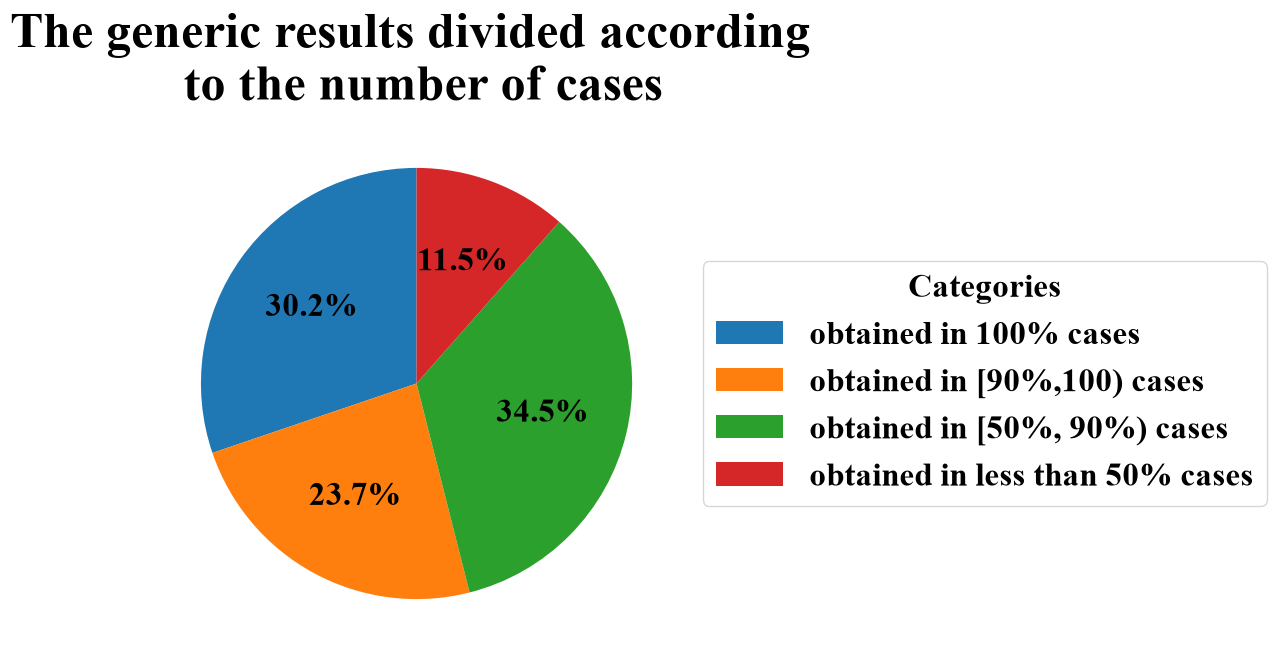

In [10]:
#plot the correspondence
labels = list(result.keys())
values = list(result.values())
plt.figure(figsize=(8,7))
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 24
plt.rcParams['font.weight'] = 'bold'
plt.gcf().patch.set_alpha(1.0)
plt.gca().patch.set_alpha(1.0)
wedges, texts, autotexts = plt.pie(
    values,
    autopct='%1.1f%%',
    startangle=90,
)

for w in wedges:
    w.set_alpha(1.0)

for t in texts + autotexts:
    t.set_alpha(1.0)

plt.legend(
    wedges,
    labels,
    title="Categories",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=24
)

plt.title('The generic results divided according \n to the number of cases', fontsize=36, fontfamily='Times New Roman', fontweight='bold')

save_path = Path("../data/fig_res")
save_path.mkdir(parents=True, exist_ok=True)

with open(os.devnull, 'w') as devnull:
        old_stderr = sys.stderr
        sys.stderr = devnull
        plt.savefig(str(save_path)+"/generic_in_indiv.eps", format='eps',dpi=500, bbox_inches='tight', transparent=False)
        sys.stderr = old_stderr
plt.show()